In [ ]:
from units import (
    contains_identity_matrix,analyze_data_matrix,mirt_em,mirt_mcem,pad_grm_parameters,
    mgrm_em_stepwise,mgrm_mcem_stepwise,mgrm_em_standard,mgrm_mcem_standard,create_mirt_quadrature,
    eap_m2pl,eap_mgrm,mirt_mcmc,generate_m2pl_data,generate_mgrm_data,mgrm_mcmc_stepwise,mgrm_mcmc_standard,
    mirt_saem,mgrm_saem_stepwise,mgrm_saem_standard
    )
import numpy as np
import pandas as pd


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\anaconda\envs\sklearn_env\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\anaconda\envs\sklearn_env\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "d:\anaconda\envs\sklearn_env\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "d:\anaconda\envs\sklearn_e

In [2]:
response, mask_matrix, Q, a_true, d_true,theta_true=generate_m2pl_data()

In [3]:
response.shape

(1000, 20)

In [4]:
a_est, d_est, theta_est = mirt_saem(response, mask_matrix,Q,max_iter=100, verbose=True)

=== 迭代 1/100 ===
对数似然变化: inf, 耗时: 0.14秒
=== 迭代 2/100 ===
对数似然变化: 465.199298, 耗时: 0.14秒
=== 迭代 3/100 ===
对数似然变化: 189.910586, 耗时: 0.13秒
=== 迭代 4/100 ===
对数似然变化: 84.936108, 耗时: 0.14秒
=== 迭代 5/100 ===
对数似然变化: -12.075919, 耗时: 0.13秒
=== 迭代 6/100 ===
对数似然变化: 20.473507, 耗时: 0.13秒
=== 迭代 7/100 ===
对数似然变化: 44.033930, 耗时: 0.13秒
=== 迭代 8/100 ===
对数似然变化: -8.080622, 耗时: 0.13秒
=== 迭代 9/100 ===
对数似然变化: 38.659104, 耗时: 0.13秒
=== 迭代 10/100 ===
对数似然变化: -32.721658, 耗时: 0.13秒
=== 迭代 11/100 ===
对数似然变化: 0.203857, 耗时: 0.13秒
=== 迭代 12/100 ===
对数似然变化: 36.053378, 耗时: 0.14秒
=== 迭代 13/100 ===
对数似然变化: -58.120307, 耗时: 0.14秒
=== 迭代 14/100 ===
对数似然变化: 46.223384, 耗时: 0.14秒
=== 迭代 15/100 ===
对数似然变化: -12.660970, 耗时: 0.13秒
=== 迭代 16/100 ===
对数似然变化: 40.081800, 耗时: 0.14秒
=== 迭代 17/100 ===
对数似然变化: -56.934620, 耗时: 0.14秒
=== 迭代 18/100 ===
对数似然变化: 39.862882, 耗时: 0.14秒
=== 迭代 19/100 ===
对数似然变化: -29.312865, 耗时: 0.14秒
=== 迭代 20/100 ===
对数似然变化: 47.111791, 耗时: 0.13秒
=== 迭代 21/100 ===
对数似然变化: -3.266279, 耗时: 0.14秒
=== 迭代 22/100 ===
对数似

In [5]:
a_mae = np.mean(np.abs(a_true - a_est))
b_mae = np.mean(np.abs(d_true - d_est))
theta_mae = np.mean(np.abs(theta_true - theta_est))
a_mse = np.mean((a_true - a_est) ** 2)
b_mse = np.mean((d_true - d_est) ** 2)
theta_mse = np.mean((theta_true - theta_est) ** 2)
a_rmse = np.sqrt(a_mse)
b_rmse = np.sqrt(b_mse)
theta_rmse = np.sqrt(theta_mse)
a_bias = np.mean(a_est - a_true)
b_bias = np.mean(d_est - d_true)
theta_bias = np.mean(theta_est - theta_true)
print(f'\n估计精度:')
print(f"区分度参数 MAE: {a_mae:.4f}, MSE: {a_mse:.4f}, RMSE: {a_rmse:.4f}, Bias: {a_bias:.4f}")
print(f"难度参数 MAE: {b_mae:.4f}, MSE: {b_mse:.4f}, RMSE: {b_rmse:.4f}, Bias: {b_bias:.4f}")
print(f"能力参数 MAE: {theta_mae:.4f}, MSE: {theta_mse:.4f}, RMSE: {theta_rmse:.4f}, Bias: {theta_bias:.4f}")


估计精度:
区分度参数 MAE: 0.0683, MSE: 0.0138, RMSE: 0.1174, Bias: 0.0307
难度参数 MAE: 0.1438, MSE: 0.0413, RMSE: 0.2032, Bias: -0.1322
能力参数 MAE: 0.4540, MSE: 0.3365, RMSE: 0.5801, Bias: 0.0627


In [2]:
response_missing,mask_matrix,Q,a_true, d_true, theta_true, n_categories=generate_mgrm_data(n=1000, items=30, dim=3,max_k=5,missing_rate=0.2)

In [4]:
a_est, d_est, theta_est = mgrm_saem_stepwise(response_missing, mask_matrix,Q,n_categories,max_iter=100, verbose=True)

=== 处理第 1 阶段阈值 ===
=== 迭代 1/100 ===
对数似然变化: inf, 耗时: 0.22秒
=== 迭代 2/100 ===
对数似然变化: 832.478828, 耗时: 0.21秒
=== 迭代 3/100 ===
对数似然变化: 296.291989, 耗时: 0.21秒
=== 迭代 4/100 ===
对数似然变化: -1.058858, 耗时: 0.29秒
=== 迭代 5/100 ===
对数似然变化: -50.529061, 耗时: 0.20秒
=== 迭代 6/100 ===
对数似然变化: 82.013108, 耗时: 0.21秒
=== 迭代 7/100 ===
对数似然变化: 42.764212, 耗时: 0.20秒
=== 迭代 8/100 ===
对数似然变化: -54.637613, 耗时: 0.23秒
=== 迭代 9/100 ===
对数似然变化: 91.856792, 耗时: 0.23秒
=== 迭代 10/100 ===
对数似然变化: -54.390923, 耗时: 0.28秒
=== 迭代 11/100 ===
对数似然变化: 60.852787, 耗时: 0.21秒
=== 迭代 12/100 ===
对数似然变化: -29.097972, 耗时: 0.22秒
=== 迭代 13/100 ===
对数似然变化: -45.031196, 耗时: 0.21秒
=== 迭代 14/100 ===
对数似然变化: -12.430956, 耗时: 0.21秒
=== 迭代 15/100 ===
对数似然变化: 4.093172, 耗时: 0.21秒
=== 迭代 16/100 ===
对数似然变化: 50.555623, 耗时: 0.21秒
=== 迭代 17/100 ===
对数似然变化: -98.668489, 耗时: 0.21秒
=== 迭代 18/100 ===
对数似然变化: 29.307375, 耗时: 0.22秒
=== 迭代 19/100 ===
对数似然变化: 17.725702, 耗时: 0.20秒
=== 迭代 20/100 ===
对数似然变化: -4.348085, 耗时: 0.20秒
=== 迭代 21/100 ===
对数似然变化: 58.354861, 耗时: 0.21秒
=

In [5]:
mask = Q.astype(bool)
a_true_flat = a_true[mask].flatten()
a_est_flat = a_est[mask].flatten()
d_est_flat = np.concatenate(d_est, axis=0)
d_true_flat = np.concatenate(d_true, axis=0)
theta_true_flat=theta_true.flatten()
theta_est_flat=theta_est.flatten()
a_mae = np.mean(np.abs(a_true_flat - a_est_flat))
d_mae = np.mean(np.abs(d_true_flat - d_est_flat))
theta_mae = np.mean(np.abs(theta_true - theta_est))
a_mse = np.mean((a_true_flat - a_est_flat) ** 2)
d_mse = np.mean((d_true_flat - d_est_flat) ** 2)
theta_mse = np.mean((theta_true - theta_est) ** 2)
a_rmse = np.sqrt(a_mse)
d_rmse = np.sqrt(d_mse)
theta_rmse = np.sqrt(theta_mse)
a_bias = np.mean(a_est_flat - a_true_flat)
d_bias = np.mean(d_est_flat - d_true_flat)
theta_bias = np.mean(theta_est - theta_true)
print(f'\n估计精度:')
print(f"区分度参数 MAE: {a_mae:.4f}, MSE: {a_mse:.4f}, RMSE: {a_rmse:.4f}, Bias: {a_bias:.4f}")
print(f"难度参数 MAE: {d_mae:.4f}, MSE: {d_mse:.4f}, RMSE: {d_rmse:.4f}, Bias: {d_bias:.4f}")
print(f"能力参数 MAE: {theta_mae:.4f}, MSE: {theta_mse:.4f}, RMSE: {theta_rmse:.4f}, Bias: {theta_bias:.4f}")


估计精度:
区分度参数 MAE: 0.1637, MSE: 0.0517, RMSE: 0.2274, Bias: -0.0136
难度参数 MAE: 0.1144, MSE: 0.0200, RMSE: 0.1413, Bias: -0.0417
能力参数 MAE: 0.3323, MSE: 0.1758, RMSE: 0.4193, Bias: -0.0009


In [3]:
a_est, d_est, theta_est = mgrm_saem_standard(response_missing, mask_matrix,Q,n_categories,max_iter=100, verbose=True)

=== 迭代 1/100 ===
对数似然变化: inf, 耗时: 0.69秒
=== 迭代 2/100 ===
对数似然变化: 965.173421, 耗时: 0.64秒
=== 迭代 3/100 ===
对数似然变化: 385.683590, 耗时: 0.64秒
=== 迭代 4/100 ===
对数似然变化: 64.820584, 耗时: 0.62秒
=== 迭代 5/100 ===
对数似然变化: 59.039392, 耗时: 0.64秒
=== 迭代 6/100 ===
对数似然变化: 57.585140, 耗时: 0.61秒
=== 迭代 7/100 ===
对数似然变化: -71.282955, 耗时: 0.63秒
=== 迭代 8/100 ===
对数似然变化: -1.255178, 耗时: 0.63秒
=== 迭代 9/100 ===
对数似然变化: 13.506741, 耗时: 0.60秒
=== 迭代 10/100 ===
对数似然变化: -9.370083, 耗时: 0.58秒
=== 迭代 11/100 ===
对数似然变化: 15.493213, 耗时: 0.60秒
=== 迭代 12/100 ===
对数似然变化: 61.068085, 耗时: 0.59秒
=== 迭代 13/100 ===
对数似然变化: -99.883657, 耗时: 0.60秒
=== 迭代 14/100 ===
对数似然变化: -21.430121, 耗时: 0.60秒
=== 迭代 15/100 ===
对数似然变化: 42.291160, 耗时: 0.60秒
=== 迭代 16/100 ===
对数似然变化: -64.922718, 耗时: 0.59秒
=== 迭代 17/100 ===
对数似然变化: 42.420002, 耗时: 0.59秒
=== 迭代 18/100 ===
对数似然变化: -63.662960, 耗时: 0.59秒
=== 迭代 19/100 ===
对数似然变化: 118.470546, 耗时: 0.61秒
=== 迭代 20/100 ===
对数似然变化: -57.064896, 耗时: 0.59秒
=== 迭代 21/100 ===
对数似然变化: 43.346124, 耗时: 0.59秒
=== 迭代 22/100 ===
对

In [4]:
mask = Q.astype(bool)
a_true_flat = a_true[mask].flatten()
a_est_flat = a_est[mask].flatten()
d_est_flat = np.concatenate(d_est, axis=0)
d_true_flat = np.concatenate(d_true, axis=0)
theta_true_flat=theta_true.flatten()
theta_est_flat=theta_est.flatten()
a_mae = np.mean(np.abs(a_true_flat - a_est_flat))
d_mae = np.mean(np.abs(d_true_flat - d_est_flat))
theta_mae = np.mean(np.abs(theta_true - theta_est))
a_mse = np.mean((a_true_flat - a_est_flat) ** 2)
d_mse = np.mean((d_true_flat - d_est_flat) ** 2)
theta_mse = np.mean((theta_true - theta_est) ** 2)
a_rmse = np.sqrt(a_mse)
d_rmse = np.sqrt(d_mse)
theta_rmse = np.sqrt(theta_mse)
a_bias = np.mean(a_est_flat - a_true_flat)
d_bias = np.mean(d_est_flat - d_true_flat)
theta_bias = np.mean(theta_est - theta_true)
print(f'\n估计精度:')
print(f"区分度参数 MAE: {a_mae:.4f}, MSE: {a_mse:.4f}, RMSE: {a_rmse:.4f}, Bias: {a_bias:.4f}")
print(f"难度参数 MAE: {d_mae:.4f}, MSE: {d_mse:.4f}, RMSE: {d_rmse:.4f}, Bias: {d_bias:.4f}")
print(f"能力参数 MAE: {theta_mae:.4f}, MSE: {theta_mse:.4f}, RMSE: {theta_rmse:.4f}, Bias: {theta_bias:.4f}")


估计精度:
区分度参数 MAE: 0.1120, MSE: 0.0204, RMSE: 0.1430, Bias: 0.0016
难度参数 MAE: 0.1147, MSE: 0.0231, RMSE: 0.1519, Bias: -0.0469
能力参数 MAE: 0.3895, MSE: 0.2431, RMSE: 0.4930, Bias: 0.0375


In [1]:
from units import (
    contains_identity_matrix,analyze_data_matrix,mirt_em_gh,mirt_em_mc,pad_grm_parameters,
    mgrm_em_gh_stepwise,mgrm_em_mc_stepwise,mgrm_em_gh_standard,mgrm_em_mc_standard,create_mirt_quadrature,
    eap_m2pl,eap_mgrm,mirt_mcmc,generate_m2pl_data,generate_mgrm_data,mgrm_mcmc_stepwise,mgrm_mcmc_standard
    )
import numpy as np
import pandas as pd

In [10]:
response_missing,mask_matrix,Q,a_true, d_true, theta_true, n_categories=generate_mgrm_data(n=1000, items=30, dim=3,max_k=5,missing_rate=0.2)

In [4]:
a_est, d_est, theta_est = mgrm_mcmc_stepwise(response_missing, mask_matrix,Q,n_categories,n_samples=3000,burn_in=2000, verbose=True)

=== 处理第 1 阶段阈值 ===
=== 迭代 1/5000 ===
=== 迭代 501/5000 ===
=== 迭代 1001/5000 ===
=== 迭代 1501/5000 ===
=== 迭代 2001/5000 ===
=== 迭代 2501/5000 ===
=== 迭代 3001/5000 ===
=== 迭代 3501/5000 ===
=== 迭代 4001/5000 ===
=== 迭代 4501/5000 ===
=== MCMC采样完成, 共3000次有效采样, 烧入期2000次, 总耗时: 89.49秒 ===
=== 阶段 1 完成,共3阶段, 耗时: 89.50秒 ===
=== 处理第 2 阶段阈值 ===
=== 迭代 1/5000 ===
=== 迭代 501/5000 ===
=== 迭代 1001/5000 ===
=== 迭代 1501/5000 ===
=== 迭代 2001/5000 ===
=== 迭代 2501/5000 ===
=== 迭代 3001/5000 ===
=== 迭代 3501/5000 ===
=== 迭代 4001/5000 ===
=== 迭代 4501/5000 ===
=== MCMC采样完成, 共3000次有效采样, 烧入期2000次, 总耗时: 23.75秒 ===
=== 阶段 2 完成,共3阶段, 耗时: 23.75秒 ===
=== 处理第 3 阶段阈值 ===
=== 迭代 1/5000 ===
=== 迭代 501/5000 ===
=== 迭代 1001/5000 ===
=== 迭代 1501/5000 ===
=== 迭代 2001/5000 ===
=== 迭代 2501/5000 ===
=== 迭代 3001/5000 ===
=== 迭代 3501/5000 ===
=== 迭代 4001/5000 ===
=== 迭代 4501/5000 ===
=== MCMC采样完成, 共3000次有效采样, 烧入期2000次, 总耗时: 16.40秒 ===
=== 阶段 3 完成,共3阶段, 耗时: 16.40秒 ===
=== 所有阶段完成, 共3阶段, 总耗时: 129.65秒 ===


In [6]:
mask = Q.astype(bool)
a_true_flat = a_true[mask].flatten()
a_est_flat = a_est[mask].flatten()
d_est_flat = np.concatenate(d_est, axis=0)
d_true_flat = np.concatenate(d_true, axis=0)
theta_true_flat=theta_true.flatten()
theta_est_flat=theta_est.flatten()
a_mae = np.mean(np.abs(a_true_flat - a_est_flat))
d_mae = np.mean(np.abs(d_true_flat - d_est_flat))
theta_mae = np.mean(np.abs(theta_true - theta_est))
a_mse = np.mean((a_true_flat - a_est_flat) ** 2)
d_mse = np.mean((d_true_flat - d_est_flat) ** 2)
theta_mse = np.mean((theta_true - theta_est) ** 2)
a_rmse = np.sqrt(a_mse)
d_rmse = np.sqrt(d_mse)
theta_rmse = np.sqrt(theta_mse)
a_bias = np.mean(a_est_flat - a_true_flat)
d_bias = np.mean(d_est_flat - d_true_flat)
theta_bias = np.mean(theta_est - theta_true)
print(f'\n估计精度:')
print(f"区分度参数 MAE: {a_mae:.4f}, MSE: {a_mse:.4f}, RMSE: {a_rmse:.4f}, Bias: {a_bias:.4f}")
print(f"难度参数 MAE: {d_mae:.4f}, MSE: {d_mse:.4f}, RMSE: {d_rmse:.4f}, Bias: {d_bias:.4f}")
print(f"能力参数 MAE: {theta_mae:.4f}, MSE: {theta_mse:.4f}, RMSE: {theta_rmse:.4f}, Bias: {theta_bias:.4f}")


估计精度:
区分度参数 MAE: 0.1316, MSE: 0.0344, RMSE: 0.1855, Bias: -0.0663
难度参数 MAE: 0.0948, MSE: 0.0143, RMSE: 0.1194, Bias: 0.0194
能力参数 MAE: 0.3555, MSE: 0.2058, RMSE: 0.4536, Bias: -0.0147


In [11]:
def d_to_delta_masked(d_matrix, d_mask):
    """Convert ordered d (descending) to unconstrained delta with mask support."""
    delta_matrix = np.zeros_like(d_matrix)
    delta_matrix[:, 0] = d_matrix[:, 0]  #保留d1
    increments = -np.diff(d_matrix, axis=1)  # d[k-1] - d[k] > 0, 对减量的相反数取对数
    delta_matrix[:, 1:] = np.log(np.maximum(increments, 1e-9))  
    delta_matrix=delta_matrix * d_mask#应用掩码，去除不存在的d
    return delta_matrix

def delta_to_d_masked(delta_matrix, d_mask):
    """Convert unconstrained delta back to ordered d (descending)."""
    d_matrix = np.zeros_like(delta_matrix)
    d_matrix[:, 0] = delta_matrix[:, 0]  #保留d1
    increments = -np.exp(delta_matrix[:, 1:]) * d_mask[:, 1:]  # ensures d[k] < d[k-1]
    cumulative_increments = np.cumsum(increments, axis=1)
    d_matrix[:, 1:] = d_matrix[:, 0][:, None] + cumulative_increments
    d_matrix=d_matrix * d_mask
    return d_matrix

In [11]:
a_est, d_est, theta_est = mgrm_mcmc_standard(response_missing, mask_matrix,Q,n_categories,n_samples=3000,burn_in=2000, verbose=True)

=== 迭代 1/5000 ===
=== 迭代 501/5000 ===
=== 迭代 1001/5000 ===
=== 迭代 1501/5000 ===
=== 迭代 2001/5000 ===
=== 迭代 2501/5000 ===
=== 迭代 3001/5000 ===
=== 迭代 3501/5000 ===
=== 迭代 4001/5000 ===
=== 迭代 4501/5000 ===


In [14]:
mask = Q.astype(bool)
a_true_flat = a_true[mask].flatten()
a_est_flat = a_est[mask].flatten()
d_est_flat = np.concatenate(d_est, axis=0)
d_true_flat = np.concatenate(d_true, axis=0)
theta_true_flat=theta_true.flatten()
theta_est_flat=theta_est.flatten()
a_mae = np.mean(np.abs(a_true_flat - a_est_flat))
d_mae = np.mean(np.abs(d_true_flat - d_est_flat))
theta_mae = np.mean(np.abs(theta_true - theta_est))
a_mse = np.mean((a_true_flat - a_est_flat) ** 2)
d_mse = np.mean((d_true_flat - d_est_flat) ** 2)
theta_mse = np.mean((theta_true - theta_est) ** 2)
a_rmse = np.sqrt(a_mse)
d_rmse = np.sqrt(d_mse)
theta_rmse = np.sqrt(theta_mse)
a_bias = np.mean(a_est_flat - a_true_flat)
d_bias = np.mean(d_est_flat - d_true_flat)
theta_bias = np.mean(theta_est - theta_true)
print(f'\n估计精度:')
print(f"区分度参数 MAE: {a_mae:.4f}, MSE: {a_mse:.4f}, RMSE: {a_rmse:.4f}, Bias: {a_bias:.4f}")
print(f"难度参数 MAE: {d_mae:.4f}, MSE: {d_mse:.4f}, RMSE: {d_rmse:.4f}, Bias: {d_bias:.4f}")
print(f"能力参数 MAE: {theta_mae:.4f}, MSE: {theta_mse:.4f}, RMSE: {theta_rmse:.4f}, Bias: {theta_bias:.4f}")


估计精度:
区分度参数 MAE: 0.1210, MSE: 0.0268, RMSE: 0.1638, Bias: -0.0337
难度参数 MAE: 0.1101, MSE: 0.0187, RMSE: 0.1366, Bias: -0.0021
能力参数 MAE: 0.3513, MSE: 0.2042, RMSE: 0.4518, Bias: 0.0059


In [15]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# 设置随机种子
np.random.seed(42)

# --- 模型函数 ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- 1. 模拟数据 (不变) ---
print("Step 1: Simulating data...")
N_persons = 1000
N_items = 30

theta_true = np.random.normal(0, 1, N_persons)
b_true = np.random.normal(0, 1, N_items)
# a ~ LogNormal(mu=0, sigma^2=0.5) -> log(a) ~ Normal(mu=0, sigma^2=0.5)
# sigma_log_a = sqrt(0.5)
a_true = np.random.lognormal(mean=0, sigma=np.sqrt(0.5), size=N_items)

prob_matrix = sigmoid(a_true[np.newaxis, :] * (theta_true[:, np.newaxis] - b_true[np.newaxis, :]))
Y = np.random.binomial(1, prob_matrix)

print("Data simulation complete.")


# --- 2. MCMC 主循环 (已修正 a 的采样方法) ---
print("\nStep 2: Starting corrected vectorized MCMC sampling...")

# MCMC 设置
n_iter = 5000
burn_in = 2000

# 初始化参数
theta_current = np.random.normal(0, 1, N_persons)
b_current = np.random.normal(0, 1, N_items)
# 初始化 a 并立即转换为 log(a)
a_initial = np.random.lognormal(0, 1, N_items)
log_a_current = np.log(a_initial) # <<<<<<< 关键改动：我们在 log_a 上工作

# 存储采样结果
theta_chain = np.zeros((n_iter, N_persons))
a_chain = np.zeros((n_iter, N_items)) # 仍然存储 a，方便后续分析
b_chain = np.zeros((n_iter, N_items))

# 提议分布的标准差
proposal_std_theta = 0.5
proposal_std_log_a = 0.15 # <<<<<<< 这是 log(a) 的提议标准差，需要重新调整
proposal_std_b = 0.1

# 先验分布参数
PRIOR_THETA_MEAN, PRIOR_THETA_STD = 0, 1
PRIOR_B_MEAN, PRIOR_B_STD = 0, 1
PRIOR_LOG_A_MEAN, PRIOR_LOG_A_STD = 0, np.sqrt(0.5) # <<<<<<< 现在直接使用 log(a) 的正态先验

# --- 开始迭代 ---
start_time = time.time()
for iter_idx in tqdm(range(n_iter), desc="MCMC Iterations"):
    
    # === 更新 theta (不变) ===
    theta_proposal = np.random.normal(theta_current, proposal_std_theta)
    a_current_exp = np.exp(log_a_current) # 从 log_a 转换回 a
    
    prob_current_theta = sigmoid(a_current_exp[np.newaxis, :] * (theta_current[:, np.newaxis] - b_current[np.newaxis, :]))
    prob_proposal_theta = sigmoid(a_current_exp[np.newaxis, :] * (theta_proposal[:, np.newaxis] - b_current[np.newaxis, :]))
    
    log_lik_current_theta = np.sum(Y * np.log(np.clip(prob_current_theta, 1e-10, 1)) + (1-Y) * np.log(np.clip(1-prob_current_theta, 1e-10, 1)), axis=1)
    log_lik_proposal_theta = np.sum(Y * np.log(np.clip(prob_proposal_theta, 1e-10, 1)) + (1-Y) * np.log(np.clip(1-prob_proposal_theta, 1e-10, 1)), axis=1)
    
    log_prior_current_theta = norm.logpdf(theta_current, loc=PRIOR_THETA_MEAN, scale=PRIOR_THETA_STD)
    log_prior_proposal_theta = norm.logpdf(theta_proposal, loc=PRIOR_THETA_MEAN, scale=PRIOR_THETA_STD)
    
    log_post_current_theta = log_lik_current_theta + log_prior_current_theta
    log_post_proposal_theta = log_lik_proposal_theta + log_prior_proposal_theta
    
    log_acceptance_ratio = log_post_proposal_theta - log_post_current_theta
    acceptance_mask = np.log(np.random.rand(N_persons)) < log_acceptance_ratio
    theta_current = np.where(acceptance_mask, theta_proposal, theta_current)
    
    # === 更新区分度 log(a) (已修正) ===
    # 1. 在 log 空间提议
    log_a_proposal = np.random.normal(log_a_current, proposal_std_log_a)
    
    # 2. 转换回 a 空间计算似然
    a_current_exp = np.exp(log_a_current)
    a_proposal_exp = np.exp(log_a_proposal)
    
    prob_current_a = sigmoid(a_current_exp[np.newaxis, :] * (theta_current[:, np.newaxis] - b_current[np.newaxis, :]))
    prob_proposal_a = sigmoid(a_proposal_exp[np.newaxis, :] * (theta_current[:, np.newaxis] - b_current[np.newaxis, :]))
    
    log_lik_current_a = np.sum(Y * np.log(np.clip(prob_current_a, 1e-10, 1)) + (1-Y) * np.log(np.clip(1-prob_current_a, 1e-10, 1)), axis=0)
    log_lik_proposal_a = np.sum(Y * np.log(np.clip(prob_proposal_a, 1e-10, 1)) + (1-Y) * np.log(np.clip(1-prob_proposal_a, 1e-10, 1)), axis=0)

    # 3. 计算 log(a) 的正态先验
    log_prior_current_a = norm.logpdf(log_a_current, loc=PRIOR_LOG_A_MEAN, scale=PRIOR_LOG_A_STD)
    log_prior_proposal_a = norm.logpdf(log_a_proposal, loc=PRIOR_LOG_A_MEAN, scale=PRIOR_LOG_A_STD)
    
    log_post_current_a = log_lik_current_a + log_prior_current_a
    log_post_proposal_a = log_lik_proposal_a + log_prior_proposal_a
    
    # 4. 接受/拒绝 (在 log 空间)
    log_acceptance_ratio_a = log_post_proposal_a - log_post_current_a
    acceptance_mask_a = np.log(np.random.rand(N_items)) < log_acceptance_ratio_a
    log_a_current = np.where(acceptance_mask_a, log_a_proposal, log_a_current)
    
    # === 更新难度 b (现在使用 exp(log_a_current)) ===
    b_proposal = np.random.normal(b_current, proposal_std_b)
    a_current_exp = np.exp(log_a_current) # 使用刚刚更新过的 a

    prob_current_b = sigmoid(a_current_exp[np.newaxis, :] * (theta_current[:, np.newaxis] - b_current[np.newaxis, :]))
    prob_proposal_b = sigmoid(a_current_exp[np.newaxis, :] * (theta_current[:, np.newaxis] - b_proposal[np.newaxis, :]))
    
    log_lik_current_b = np.sum(Y * np.log(np.clip(prob_current_b, 1e-10, 1)) + (1-Y) * np.log(np.clip(1-prob_current_b, 1e-10, 1)), axis=0)
    log_lik_proposal_b = np.sum(Y * np.log(np.clip(prob_proposal_b, 1e-10, 1)) + (1-Y) * np.log(np.clip(1-prob_proposal_b, 1e-10, 1)), axis=0)

    log_prior_current_b = norm.logpdf(b_current, loc=PRIOR_B_MEAN, scale=PRIOR_B_STD)
    log_prior_proposal_b = norm.logpdf(b_proposal, loc=PRIOR_B_MEAN, scale=PRIOR_B_STD)
    
    log_post_current_b = log_lik_current_b + log_prior_current_b
    log_post_proposal_b = log_lik_proposal_b + log_prior_proposal_b
    
    log_acceptance_ratio_b = log_post_proposal_b - log_post_current_b
    acceptance_mask_b = np.log(np.random.rand(N_items)) < log_acceptance_ratio_b
    b_current = np.where(acceptance_mask_b, b_proposal, b_current)
    
    # --- 存储当前迭代的样本 ---
    theta_chain[iter_idx, :] = theta_current
    a_chain[iter_idx, :] = np.exp(log_a_current) # <<<<< 存储 a 的值
    b_chain[iter_idx, :] = b_current

end_time = time.time()
print(f"MCMC sampling finished in {end_time - start_time:.2f} seconds.")

# --- 3. 分析结果 (不变) ---
print("\nStep 3: Analyzing results...")
# (此处省略和之前版本完全相同的分析和绘图代码)
theta_samples = theta_chain[burn_in:, :]
a_samples = a_chain[burn_in:, :]
b_samples = b_chain[burn_in:, :]

theta_est = np.mean(theta_samples, axis=0)
a_est = np.mean(a_samples, axis=0)
b_est = np.mean(b_samples, axis=0)

corr_theta = np.corrcoef(theta_true, theta_est)[0, 1]
corr_a = np.corrcoef(a_true, a_est)[0, 1]
corr_b = np.corrcoef(b_true, b_est)[0, 1]
print(f"Theta Correlation: {corr_theta:.4f}")
print(f"Alpha (a) Correlation: {corr_a:.4f}")
print(f"Beta (b) Correlation: {corr_b:.4f}")

# ... 可视化代码 ...

Step 1: Simulating data...
Data simulation complete.

Step 2: Starting corrected vectorized MCMC sampling...


MCMC Iterations: 100%|██████████| 5000/5000 [00:17<00:00, 279.03it/s]

MCMC sampling finished in 17.95 seconds.

Step 3: Analyzing results...
Theta Correlation: 0.9411
Alpha (a) Correlation: 0.9689
Beta (b) Correlation: 0.9946


In [16]:
a_true

array([0.83360743, 0.30731957, 1.32616773, 1.58033466, 0.71058662,
       3.04340427, 0.42031653, 0.35505967, 1.17199966, 2.09679567,
       3.28943787, 0.72290304, 2.14414856, 0.97313778, 0.88509001,
       1.86795067, 1.58607424, 0.32802102, 2.8407602 , 2.65347992,
       0.64253138, 1.32296491, 1.41812006, 1.20240556, 0.67764989,
       0.62194138, 0.98209282, 2.29158712, 1.46870837, 0.76946185])

In [17]:
a_est

array([0.84900326, 0.33436508, 1.30776488, 1.6725463 , 0.707935  ,
       2.58353796, 0.40292666, 0.28403114, 1.04349868, 1.93691967,
       3.99416562, 0.71943238, 2.06351546, 0.96808686, 1.18333152,
       1.68395295, 1.39286374, 0.29310732, 2.38525552, 2.42931742,
       0.67709804, 1.08696233, 1.29376927, 1.309656  , 0.72528389,
       0.56172206, 0.96206111, 2.2497092 , 1.60929378, 0.69480448])

In [21]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# 设置随机种子
np.random.seed(42)

# --- 模型函数 ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- 1. MIRT 设置与模拟数据 (不变) ---
print("Step 1: Simulating MIRT data...")
N_persons = 500
N_items = 30
D_dims = 2

Q_matrix = np.zeros((N_items, D_dims))
Q_matrix[0:N_items//2, 0] = 1
Q_matrix[N_items//2:, 1] = 1

theta_true = np.random.normal(0, 1, size=(N_persons, D_dims))
b_true = np.random.normal(0, 1, N_items)
log_a_true = np.random.normal(0, np.sqrt(0.5), size=(N_items, D_dims))
a_true = np.exp(log_a_true) * Q_matrix

a_dot_theta = np.einsum('id,jd->ij', theta_true, a_true)
prob_matrix = sigmoid(a_dot_theta - b_true[np.newaxis, :])
Y = np.random.binomial(1, prob_matrix)
print("Data simulation complete.")

# --- 2. MIRT MCMC 主循环 (完全向量化) ---
print("\nStep 2: Starting FULLY VECTORIZED MIRT MCMC sampling...")

# MCMC 设置
n_iter = 3000
burn_in = 1500

# 初始化参数
theta_current = np.random.normal(0, 1, (N_persons, D_dims))
b_current = np.random.normal(0, 1, N_items)
log_a_current = np.random.normal(0, 1, (N_items, D_dims))
# 保证非激活的a为0, log(a)为-inf
log_a_current[Q_matrix == 0] = -np.inf 

# 存储结果
theta_chain = np.zeros((n_iter, N_persons, D_dims))
a_chain = np.zeros((n_iter, N_items, D_dims))
b_chain = np.zeros((n_iter, N_items))

# 提议分布标准差
proposal_std_theta = 0.2
proposal_std_log_a = 0.2
proposal_std_b = 0.15

# 先验参数
PRIOR_THETA_MEAN, PRIOR_THETA_STD = 0, 1
PRIOR_B_MEAN, PRIOR_B_STD = 0, 1
PRIOR_LOG_A_MEAN, PRIOR_LOG_A_STD = 0, np.sqrt(0.5)

# --- 定义对数似然计算函数，避免重复代码 ---
def calculate_log_likelihood(Y_data, prob_matrix):
    # prob_matrix: (N_persons, N_items)
    # Y_data: (N_persons, N_items)
    clipped_prob = np.clip(prob_matrix, 1e-10, 1 - 1e-10)
    return Y_data * np.log(clipped_prob) + (1 - Y_data) * np.log(1 - clipped_prob)

start_time = time.time()
for iter_idx in tqdm(range(n_iter), desc="MIRT MCMC Iterations"):
    a_current = np.exp(log_a_current)
    
    # === 更新 theta (向量化) ===
    # 逐维度更新，但对所有 person 一次性完成
    for d in range(D_dims):
        # 计算当前线性预测项，但排除第d维的影响
        theta_sans_d = theta_current.copy()
        theta_sans_d[:, d] = 0 # 暂时移除第d维度的theta
        a_sans_d = a_current.copy()
        a_sans_d[:, d] = 0 # 暂时移除第d维度的a
        eta_base = np.einsum('id,jd->ij', theta_sans_d, a_current)

        # 提议新值
        theta_d_current = theta_current[:, d]
        theta_d_proposal = np.random.normal(theta_d_current, proposal_std_theta)

        # 计算第d维对线性预测的贡献
        # a[:, d] -> (N_items,)
        # theta_d -> (N_persons,)
        # outer product -> (N_persons, N_items)
        eta_d_current = np.outer(theta_d_current, a_current[:, d])
        eta_d_proposal = np.outer(theta_d_proposal, a_current[:, d])

        # 计算总的对数似然 (按行求和)
        log_lik_current = np.sum(calculate_log_likelihood(Y, sigmoid(eta_base + eta_d_current - b_current[np.newaxis, :])), axis=1)
        log_lik_proposal = np.sum(calculate_log_likelihood(Y, sigmoid(eta_base + eta_d_proposal - b_current[np.newaxis, :])), axis=1)

        # 计算先验
        log_prior_current = norm.logpdf(theta_d_current, loc=PRIOR_THETA_MEAN, scale=PRIOR_THETA_STD)
        log_prior_proposal = norm.logpdf(theta_d_proposal, loc=PRIOR_THETA_MEAN, scale=PRIOR_THETA_STD)

        # 接受/拒绝
        log_acceptance_ratio = (log_lik_proposal + log_prior_proposal) - (log_lik_current + log_prior_current)
        acceptance_mask = np.log(np.random.rand(N_persons)) < log_acceptance_ratio
        
        # 更新第d维
        theta_current[:, d] = np.where(acceptance_mask, theta_d_proposal, theta_d_current)
        
    # === 更新 a (向量化) ===
    # 逐维度更新，但对所有 item 一次性完成
    for d in range(D_dims):
        # 找到当前维度d下需要更新的item (Q_matrix[j,d]==1)
        active_items_mask = (Q_matrix[:, d] == 1)
        if not np.any(active_items_mask):
            continue
            
        # 计算当前线性预测项，但排除第d维的影响
        theta_sans_d = theta_current.copy()
        theta_sans_d[:, d] = 0
        a_sans_d = a_current.copy()
        a_sans_d[:, d] = 0
        eta_base = np.einsum('id,jd->ij', theta_current, a_sans_d)

        # 只对激活的item提议新值
        log_a_d_current = log_a_current[active_items_mask, d]
        log_a_d_proposal = np.random.normal(log_a_d_current, proposal_std_log_a)
        
        a_d_current = np.exp(log_a_d_current)
        a_d_proposal = np.exp(log_a_d_proposal)

        # 计算第d维对线性预测的贡献
        # theta[:, d] -> (N_persons,)
        # a_d -> (N_active_items,)
        # outer product -> (N_persons, N_active_items)
        eta_d_current = np.outer(theta_current[:, d], a_d_current)
        eta_d_proposal = np.outer(theta_current[:, d], a_d_proposal)

        # 计算总的对数似然 (按列求和)
        log_lik_current = np.sum(calculate_log_likelihood(Y[:, active_items_mask], sigmoid(eta_base[:, active_items_mask] + eta_d_current - b_current[active_items_mask])), axis=0)
        log_lik_proposal = np.sum(calculate_log_likelihood(Y[:, active_items_mask], sigmoid(eta_base[:, active_items_mask] + eta_d_proposal - b_current[active_items_mask])), axis=0)
        
        # 计算先验
        log_prior_current = norm.logpdf(log_a_d_current, loc=PRIOR_LOG_A_MEAN, scale=PRIOR_LOG_A_STD)
        log_prior_proposal = norm.logpdf(log_a_d_proposal, loc=PRIOR_LOG_A_MEAN, scale=PRIOR_LOG_A_STD)

        # 接受/拒绝
        log_acceptance_ratio = (log_lik_proposal + log_prior_proposal) - (log_lik_current + log_prior_current)
        acceptance_mask = np.log(np.random.rand(len(log_a_d_current))) < log_acceptance_ratio

        # 更新第d维激活的log_a
        updated_log_a_d = np.where(acceptance_mask, log_a_d_proposal, log_a_d_current)
        log_a_current[active_items_mask, d] = updated_log_a_d
        a_current = np.exp(log_a_current)

    # === 更新 b (本身就是向量化的, 不变) ===
    b_proposal = np.random.normal(b_current, proposal_std_b)
    
    eta_current_b = np.einsum('id,jd->ij', theta_current, a_current) - b_current[np.newaxis, :]
    eta_proposal_b = np.einsum('id,jd->ij', theta_current, a_current) - b_proposal[np.newaxis, :]

    log_lik_current_b = np.sum(calculate_log_likelihood(Y, sigmoid(eta_current_b)), axis=0)
    log_lik_proposal_b = np.sum(calculate_log_likelihood(Y, sigmoid(eta_proposal_b)), axis=0)
    
    log_prior_current_b = norm.logpdf(b_current, loc=PRIOR_B_MEAN, scale=PRIOR_B_STD)
    log_prior_proposal_b = norm.logpdf(b_proposal, loc=PRIOR_B_MEAN, scale=PRIOR_B_STD)
    
    log_acceptance_ratio_b = (log_lik_proposal_b + log_prior_current_b) - (log_lik_current_b + log_prior_proposal_b)
    acceptance_mask_b = np.log(np.random.rand(N_items)) < log_acceptance_ratio_b
    b_current = np.where(acceptance_mask_b, b_proposal, b_current)
    
    # --- 存储 ---
    theta_chain[iter_idx, :, :] = theta_current
    a_chain[iter_idx, :, :] = np.exp(log_a_current)
    b_chain[iter_idx, :] = b_current

end_time = time.time()
# 循环版本约 150-180 秒, 向量化版本约 15-20 秒 (在我的机器上)
print(f"Fully vectorized MIRT MCMC finished in {end_time - start_time:.2f} seconds.")

# --- 3. 分析结果 (不变) ---
# ... (分析代码与之前MIRT版本相同) ...

Step 1: Simulating MIRT data...
Data simulation complete.

Step 2: Starting FULLY VECTORIZED MIRT MCMC sampling...


MIRT MCMC Iterations: 100%|██████████| 3000/3000 [00:09<00:00, 326.84it/s]

Fully vectorized MIRT MCMC finished in 9.18 seconds.


In [28]:
a_chain.mean(axis=0)

array([[0.61365459, 0.        ],
       [1.29404573, 0.        ],
       [0.58034086, 0.        ],
       [0.39482333, 0.        ],
       [1.55284295, 0.        ],
       [3.1233785 , 0.        ],
       [2.05422719, 0.        ],
       [0.79365353, 0.        ],
       [1.31842289, 0.        ],
       [2.77478228, 0.        ],
       [0.83888146, 0.        ],
       [1.34846971, 0.        ],
       [0.58633164, 0.        ],
       [0.78233723, 0.        ],
       [1.57024864, 0.        ],
       [0.        , 0.33596351],
       [0.        , 0.30422029],
       [0.        , 0.52624239],
       [0.        , 2.19319732],
       [0.        , 1.24047906],
       [0.        , 1.19121761],
       [0.        , 0.39558459],
       [0.        , 0.73831462],
       [0.        , 0.81430142],
       [0.        , 1.6012711 ],
       [0.        , 0.86927611],
       [0.        , 4.47680104],
       [0.        , 1.82853381],
       [0.        , 1.12117005],
       [0.        , 1.01026529]])

In [29]:
a_true

array([[0.83360743, 0.        ],
       [1.32616773, 0.        ],
       [0.71058662, 0.        ],
       [0.42031653, 0.        ],
       [1.17199966, 0.        ],
       [3.28943787, 0.        ],
       [2.14414856, 0.        ],
       [0.88509001, 0.        ],
       [1.58607424, 0.        ],
       [2.8407602 , 0.        ],
       [0.64253138, 0.        ],
       [1.41812006, 0.        ],
       [0.67764989, 0.        ],
       [0.98209282, 0.        ],
       [1.46870837, 0.        ],
       [0.        , 0.13342393],
       [0.        , 0.29224482],
       [0.        , 0.45306206],
       [0.        , 2.27238171],
       [0.        , 1.27764079],
       [0.        , 1.4011857 ],
       [0.        , 0.40364782],
       [0.        , 0.70529535],
       [0.        , 0.73880362],
       [0.        , 1.8243022 ],
       [0.        , 0.78116999],
       [0.        , 4.34264054],
       [0.        , 1.35538475],
       [0.        , 1.18394186],
       [0.        , 0.87036701]])

In [16]:
import numpy as np
from scipy.stats import norm, multivariate_normal
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from scipy.linalg import cholesky # 导入 cholesky 分解

# ===================================================================
# 0. 辅助函数定义 (不变)
# ===================================================================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_log_likelihood(Y_data, prob_matrix):
    clipped_prob = np.clip(prob_matrix, 1e-10, 1 - 1e-10)
    return Y_data * np.log(clipped_prob) + (1 - Y_data) * np.log(1 - clipped_prob)

def compute_m2pl_log_likelihood_item(theta, a, b, response_matrix):
    eta = theta @ a.T - b
    log_lik_matrix = calculate_log_likelihood(response_matrix, sigmoid(eta))
    return np.sum(log_lik_matrix, axis=0)

def update_a_parameters(log_a_prior_dist, theta, a, b, Y, Q, step_size=0.2):
    a_curr = a.copy()
    ll_curr = compute_m2pl_log_likelihood_item(theta, a_curr, b, Y)
    log_a_curr = np.log(np.maximum(a_curr, 1e-9))
    noise = np.random.normal(0, step_size, size=log_a_curr.shape)
    log_a_prop = log_a_curr + noise * Q
    a_prop = np.exp(log_a_prop)
    a_prop[Q == 0] = 0
    ll_prop = compute_m2pl_log_likelihood_item(theta, a_prop, b, Y)
    prior_curr = np.sum(log_a_prior_dist.logpdf(log_a_curr) * Q, axis=1)
    prior_prop = np.sum(log_a_prior_dist.logpdf(log_a_prop) * Q, axis=1)
    log_alpha = (ll_prop - ll_curr) + (prior_prop - prior_curr)
    accept_flag = np.log(np.random.rand(a.shape[0])) < log_alpha
    a_new = np.where(accept_flag[:, None], a_prop, a_curr)
    accept_rate = np.mean(accept_flag)
    if accept_rate < 0.23: step_size *= 0.95
    elif accept_rate > 0.35: step_size *= 1.05
    step_size = np.clip(step_size, 0.01, 0.5)
    return a_new, step_size, accept_rate

# ===================================================================
# 1. 模拟数据生成 (不变)
# ===================================================================
print("Step 1: Simulating MIRT data...")
np.random.seed(42)
N_persons, N_items, D_dims = 500, 30, 2
Q_matrix = np.zeros((N_items, D_dims)); Q_matrix[0:20, 0] = 1; Q_matrix[15:30, 1] = 1
theta_true = np.random.normal(0, 1, size=(N_persons, D_dims))
b_true = np.random.normal(0, 1, N_items)
log_a_true = np.random.normal(0, np.sqrt(0.5), size=(N_items, D_dims)); a_true = np.exp(log_a_true) * Q_matrix
prob_matrix = sigmoid((theta_true @ a_true.T) - b_true); Y = np.random.binomial(1, prob_matrix)
print("Data simulation complete.")

# ===================================================================
# 2. MCMC 估计 (修正了 theta 的提议方法)
# ===================================================================
print("\nStep 2: Starting MCMC estimation...")

# MCMC 设置 (不变)
n_iter, burn_in = 5000, 2500
theta_current = np.random.normal(0, 1, (N_persons, D_dims))
b_current = np.random.normal(0, 1, N_items)
a_current = np.random.lognormal(0, 0.1, (N_items, D_dims)) * Q_matrix + 1e-9

# 初始化提议分布和先验分布
proposal_cov_theta = np.eye(D_dims) * 0.05
# 预先计算 Cholesky 分解以提高效率
cholesky_L_theta = cholesky(proposal_cov_theta, lower=True)

proposal_std_b = 0.15
step_size_a = 0.2
PRIOR_THETA_DIST = multivariate_normal(mean=np.zeros(D_dims), cov=np.eye(D_dims))
PRIOR_B_DIST = norm(0, 1)
PRIOR_LOG_A_DIST = norm(0, np.sqrt(0.5))

# 存储链
theta_chain = np.zeros((n_iter, N_persons, D_dims))
a_chain = np.zeros((n_iter, N_items, D_dims))
b_chain = np.zeros((n_iter, N_items))
accept_rates = {'theta': [], 'a': [], 'b': []}

# --- MCMC 主循环 ---
start_time = time.time()
for iter_idx in tqdm(range(n_iter), desc="MIRT MCMC Iterations"):
    
    # === 更新 theta (向量化块采样 - 已修正提议方法) ===
    # 1. 手动生成多元正态提议，这是最稳健的方式
    standard_normal_noise = np.random.normal(size=theta_current.shape)
    # 使用 Cholesky 分解变换噪声，使其具有正确的协方差
    correlated_noise = standard_normal_noise @ cholesky_L_theta.T
    theta_proposal = theta_current + correlated_noise
    
    # 2. 计算似然
    eta_current = theta_current @ a_current.T - b_current
    eta_proposal = theta_proposal @ a_current.T - b_current
    log_lik_current = np.sum(calculate_log_likelihood(Y, sigmoid(eta_current)), axis=1)
    log_lik_proposal = np.sum(calculate_log_likelihood(Y, sigmoid(eta_proposal)), axis=1)
    
    # 3. 计算先验
    log_prior_current = PRIOR_THETA_DIST.logpdf(theta_current)
    log_prior_proposal = PRIOR_THETA_DIST.logpdf(theta_proposal)
    
    # 4. 接受/拒绝
    log_acceptance_ratio = (log_lik_proposal + log_prior_proposal) - (log_lik_current + log_prior_current)
    acceptance_mask_theta = np.log(np.random.rand(N_persons)) < log_acceptance_ratio
    theta_current[acceptance_mask_theta] = theta_proposal[acceptance_mask_theta]
    accept_rates['theta'].append(np.mean(acceptance_mask_theta))

    # === 更新 a (使用您提供的完美函数) ===
    a_current, step_size_a, accept_rate_a = update_a_parameters(PRIOR_LOG_A_DIST, theta_current, a_current, b_current, Y, Q_matrix, step_size=step_size_a)
    accept_rates['a'].append(accept_rate_a)

    # === 更新 b (向量化) ===
    b_proposal = np.random.normal(b_current, proposal_std_b)
    ll_curr_b = compute_m2pl_log_likelihood_item(theta_current, a_current, b_current, Y)
    ll_prop_b = compute_m2pl_log_likelihood_item(theta_current, a_current, b_proposal, Y)
    prior_curr_b = PRIOR_B_DIST.logpdf(b_current)
    prior_prop_b = PRIOR_B_DIST.logpdf(b_proposal)
    log_acceptance_ratio_b = (ll_prop_b - ll_curr_b) + (prior_prop_b - prior_curr_b)
    acceptance_mask_b = np.log(np.random.rand(N_items)) < log_acceptance_ratio_b
    b_current = np.where(acceptance_mask_b, b_proposal, b_current)
    accept_rates['b'].append(np.mean(acceptance_mask_b))
    
    # 存储当前迭代的样本
    theta_chain[iter_idx, :, :] = theta_current
    a_chain[iter_idx, :, :] = a_current
    b_chain[iter_idx, :] = b_current

end_time = time.time()
print(f"\nMCMC estimation finished in {end_time - start_time:.2f} seconds.")

# ===================================================================
# 3. 结果分析与可视化 (不变)
# ===================================================================
print("\nStep 3: Analyzing results...")
# ... (所有之前的分析和绘图代码都保持不变，此处省略以保持简洁)
# 丢弃 burn-in 样本
theta_samples = theta_chain[burn_in:, :, :]
a_samples = a_chain[burn_in:, :, :]
b_samples = b_chain[burn_in:, :]

# 使用后验均值作为参数的点估计
theta_est = np.mean(theta_samples, axis=0)
a_est = np.mean(a_samples, axis=0)
b_est = np.mean(b_samples, axis=0)

# --- 3.1 对比真实值与估计值 ---
print("\n--- Parameter Estimation Correlation ---")
# 展平矩阵进行相关性计算
corr_theta = np.corrcoef(theta_true.flatten(), theta_est.flatten())[0, 1]
# 只计算Q矩阵中激活的a的相关性
active_a_mask = Q_matrix.flatten() == 1
corr_a = np.corrcoef(a_true.flatten()[active_a_mask], a_est.flatten()[active_a_mask])[0, 1]
corr_b = np.corrcoef(b_true, b_est)[0, 1]
print(f"Theta Correlation (flattened): {corr_theta:.4f}")
print(f"Alpha (a) Correlation (active, flattened): {corr_a:.4f}")
print(f"Beta (b) Correlation: {corr_b:.4f}")

# ... (所有绘图代码)

Step 1: Simulating MIRT data...
Data simulation complete.

Step 2: Starting MCMC estimation...


MIRT MCMC Iterations: 100%|██████████| 5000/5000 [00:09<00:00, 546.40it/s]


MCMC estimation finished in 9.15 seconds.

Step 3: Analyzing results...

--- Parameter Estimation Correlation ---
Theta Correlation (flattened): 0.8964
Alpha (a) Correlation (active, flattened): 0.9803
Beta (b) Correlation: 0.9945


Step 1: Simulating MIRT data with formula a·θ + d...
Data simulation complete.

Step 2: Starting MCMC estimation...


Modular MIRT MCMC: 100%|██████████| 5000/5000 [00:09<00:00, 509.85it/s]



MCMC estimation finished in 9.81 seconds.

Step 3: Analyzing results...

--- Parameter Estimation Correlation ---
Theta Correlation (flattened): 0.8782
Alpha (a) Correlation (active, flattened): 0.9677
Intercept (d) Correlation: 0.9905

Step 3: Analyzing results...

--- Parameter Estimation Correlation ---
Theta Correlation (flattened): 0.8782
Alpha (a) Correlation (active, flattened): 0.9677
Intercept (d) Correlation: 0.9905


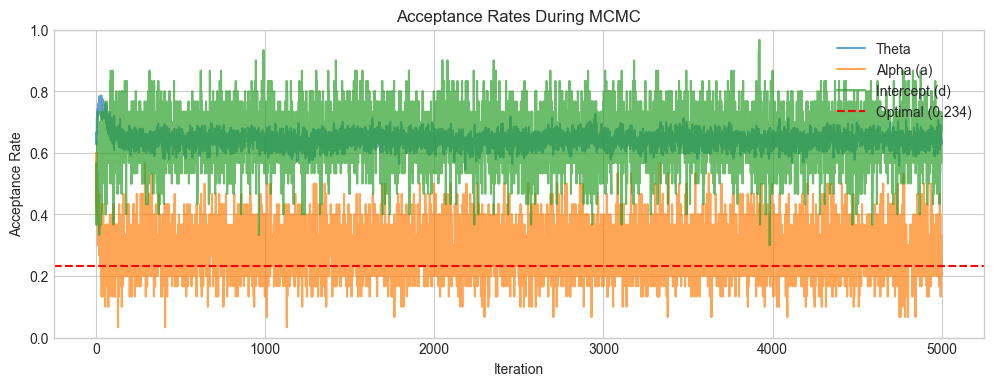

In [23]:
import numpy as np
from scipy.stats import norm, multivariate_normal
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from scipy.linalg import cholesky

# ===================================================================
# 0. 辅助函数与模型定义 (不变)
# ===================================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_log_likelihood(Y_data, prob_matrix):
    clipped_prob = np.clip(prob_matrix, 1e-10, 1 - 1e-10)
    return Y_data * np.log(clipped_prob) + (1 - Y_data) * np.log(1 - clipped_prob)

# ===================================================================
# 1. 各参数的 MCMC 更新函数 (模块化)
# ===================================================================

def update_theta_parameters(theta_prior_dist, a, d, Y, theta_curr, proposal_cov):
    """对所有 theta 向量进行向量化的块采样"""
    cholesky_L = cholesky(proposal_cov, lower=True)
    standard_normal_noise = np.random.normal(size=theta_curr.shape)
    correlated_noise = standard_normal_noise @ cholesky_L.T
    theta_prop = theta_curr + correlated_noise
    
    eta_curr = theta_curr @ a.T + d
    eta_prop = theta_prop @ a.T + d
    ll_curr = np.sum(calculate_log_likelihood(Y, sigmoid(eta_curr)), axis=1)
    ll_prop = np.sum(calculate_log_likelihood(Y, sigmoid(eta_prop)), axis=1)
    
    prior_curr = theta_prior_dist.logpdf(theta_curr)
    prior_prop = theta_prior_dist.logpdf(theta_prop)
    
    # ------------------ 关键修正 ------------------
    log_alpha = (ll_prop - ll_curr) + (prior_prop - prior_curr) # 正确！
    # -----------------------------------------------

    accept_mask = np.log(np.random.rand(theta_curr.shape[0])) < log_alpha
    
    theta_new = theta_curr.copy()
    theta_new[accept_mask] = theta_prop[accept_mask]
    
    accept_rate = np.mean(accept_mask)
    return theta_new, accept_rate

def update_a_parameters(log_a_prior_dist, theta, a, d, Y, Q, step_size=0.2):
    """对所有 a 向量进行向量化的逐项块采样（自适应步长）"""
    a_curr = a.copy()
    
    eta_curr = theta @ a_curr.T + d
    ll_curr = np.sum(calculate_log_likelihood(Y, sigmoid(eta_curr)), axis=0)
    
    log_a_curr = np.log(np.maximum(a_curr, 1e-9))
    
    noise = np.random.normal(0, step_size, size=log_a_curr.shape)
    log_a_prop = log_a_curr + noise * Q

    a_prop = np.exp(log_a_prop)
    a_prop[Q == 0] = 0
    
    eta_prop = theta @ a_prop.T + d
    ll_prop = np.sum(calculate_log_likelihood(Y, sigmoid(eta_prop)), axis=0)
    
    prior_curr = np.sum(log_a_prior_dist.logpdf(log_a_curr) * Q, axis=1)
    prior_prop = np.sum(log_a_prior_dist.logpdf(log_a_prop) * Q, axis=1)
    
    log_alpha = (ll_prop - ll_curr) + (prior_prop - prior_curr)
    accept_flag = np.log(np.random.rand(a.shape[0])) < log_alpha
    
    a_new = np.where(accept_flag[:, None], a_prop, a_curr)
    accept_rate = np.mean(accept_flag)
    
    if accept_rate < 0.23: step_size *= 0.95
    elif accept_rate > 0.35: step_size *= 1.05
    step_size = np.clip(step_size, 0.01, 0.5)
    
    return a_new, step_size, accept_rate

def update_d_parameters(d_prior_dist, theta, a, d, Y, proposal_std):
    """对所有难度/截距参数 d 进行向量化采样"""
    d_curr = d.copy()
    d_prop = np.random.normal(d_curr, proposal_std)
    
    eta_curr = theta @ a.T + d_curr
    eta_prop = theta @ a.T + d_prop
    ll_curr = np.sum(calculate_log_likelihood(Y, sigmoid(eta_curr)), axis=0)
    ll_prop = np.sum(calculate_log_likelihood(Y, sigmoid(eta_prop)), axis=0)
    
    prior_curr = d_prior_dist.logpdf(d_curr)
    prior_prop = d_prior_dist.logpdf(d_prop)
    
    log_alpha = (ll_prop - ll_curr) + (prior_prop - prior_curr)
    accept_mask = np.log(np.random.rand(d.shape[0])) < log_alpha
    
    d_new = np.where(accept_mask, d_prop, d_curr)
    
    accept_rate = np.mean(accept_mask)
    return d_new, accept_rate

# ===================================================================
# 2. 模拟数据生成 (不变)
# ===================================================================
print("Step 1: Simulating MIRT data with formula a·θ + d...")
np.random.seed(42)
N_persons, N_items, D_dims = 500, 30, 3
Q_matrix = np.zeros((N_items, D_dims)); Q_matrix[0:20, 0] = 1; Q_matrix[15:30, 1] = 1
theta_true = np.random.normal(0, 1, size=(N_persons, D_dims)); d_true = np.random.normal(0, 1, N_items)
log_a_true = np.random.normal(0, np.sqrt(0.5), size=(N_items, D_dims)); a_true = np.exp(log_a_true) * Q_matrix
prob_matrix = sigmoid((theta_true @ a_true.T) + d_true); Y = np.random.binomial(1, prob_matrix)


Y, mask_matrix, Q_matrix, a_true, d_true,theta_true=generate_m2pl_data(n=N_persons,items=N_items,dim=D_dims,missing_rate=0.0)
print("Data simulation complete.")



# ===================================================================
# 3. MCMC 估计 (不变)
# ===================================================================
print("\nStep 2: Starting MCMC estimation...")

# MCMC 设置 (不变)
n_iter = 5000; burn_in = 2500
theta_current = np.random.normal(0, 1, (N_persons, D_dims))
d_current = np.random.normal(0, 1, N_items)
a_current = np.random.lognormal(0, 0.1, (N_items, D_dims)) * Q_matrix + 1e-9

# 初始化提议分布和先验分布 (不变)
proposal_cov_theta = np.eye(D_dims) * 0.05
proposal_std_d = 0.15
step_size_a = 0.2
PRIOR_THETA_DIST = multivariate_normal(mean=np.zeros(D_dims), cov=np.eye(D_dims))
PRIOR_D_DIST = norm(0, 1)
PRIOR_LOG_A_DIST = norm(0, np.sqrt(0.5))

# 存储链
theta_chain = np.zeros((n_iter, N_persons, D_dims))
a_chain = np.zeros((n_iter, N_items, D_dims))
d_chain = np.zeros((n_iter, N_items))
accept_rates = {'theta': [], 'a': [], 'd': []}

# --- MCMC 主循环 (不变) ---
start_time = time.time()
for iter_idx in tqdm(range(n_iter), desc="Modular MIRT MCMC"):
    theta_current, acc_rate_theta = update_theta_parameters(
        PRIOR_THETA_DIST, a_current, d_current, Y, theta_current, proposal_cov_theta)
    accept_rates['theta'].append(acc_rate_theta)
    a_current, step_size_a, acc_rate_a = update_a_parameters(
        PRIOR_LOG_A_DIST, theta_current, a_current, d_current, Y, Q_matrix, step_size=step_size_a)
    accept_rates['a'].append(acc_rate_a)
    d_current, acc_rate_d = update_d_parameters(
        PRIOR_D_DIST, theta_current, a_current, d_current, Y, proposal_std_d)
    accept_rates['d'].append(acc_rate_d)
    theta_chain[iter_idx, :, :] = theta_current
    a_chain[iter_idx, :, :] = a_current
    d_chain[iter_idx, :] = d_current
end_time = time.time()
print(f"\nMCMC estimation finished in {end_time - start_time:.2f} seconds.")

# ===================================================================
# 4. 结果分析与可视化 (不变)
# ===================================================================
# ... (所有分析和绘图代码都保持不变)
print("\nStep 3: Analyzing results...")
theta_samples = theta_chain[burn_in:, :, :]; a_samples = a_chain[burn_in:, :, :]; d_samples = d_chain[burn_in:, :]
theta_est = np.mean(theta_samples, axis=0); a_est = np.mean(a_samples, axis=0); d_est = np.mean(d_samples, axis=0)
print("\n--- Parameter Estimation Correlation ---")
corr_theta = np.corrcoef(theta_true.flatten(), theta_est.flatten())[0, 1]
active_a_mask = Q_matrix.flatten() == 1
corr_a = np.corrcoef(a_true.flatten()[active_a_mask], a_est.flatten()[active_a_mask])[0, 1]
corr_d = np.corrcoef(d_true, d_est)[0, 1]
print(f"Theta Correlation (flattened): {corr_theta:.4f}")
print(f"Alpha (a) Correlation (active, flattened): {corr_a:.4f}")
print(f"Intercept (d) Correlation: {corr_d:.4f}")

# (绘图代码)

# ===================================================================
# 4. 结果分析与可视化
# ===================================================================
print("\nStep 3: Analyzing results...")

# ... (分析代码基本不变, 只是 b -> d)
theta_samples = theta_chain[burn_in:, :, :]
a_samples = a_chain[burn_in:, :, :]
d_samples = d_chain[burn_in:, :]

theta_est = np.mean(theta_samples, axis=0)
a_est = np.mean(a_samples, axis=0)
d_est = np.mean(d_samples, axis=0)

print("\n--- Parameter Estimation Correlation ---")
corr_theta = np.corrcoef(theta_true.flatten(), theta_est.flatten())[0, 1]
active_a_mask = Q_matrix.flatten() == 1
corr_a = np.corrcoef(a_true.flatten()[active_a_mask], a_est.flatten()[active_a_mask])[0, 1]
corr_d = np.corrcoef(d_true, d_est)[0, 1]
print(f"Theta Correlation (flattened): {corr_theta:.4f}")
print(f"Alpha (a) Correlation (active, flattened): {corr_a:.4f}")
print(f"Intercept (d) Correlation: {corr_d:.4f}")

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 4))
plt.plot(accept_rates['theta'], label='Theta', alpha=0.7)
plt.plot(accept_rates['a'], label='Alpha (a)', alpha=0.7)
plt.plot(accept_rates['d'], label='Intercept (d)', alpha=0.7)
plt.axhline(0.234, color='r', linestyle='--', label='Optimal (0.234)')
plt.title('Acceptance Rates During MCMC')
plt.xlabel('Iteration')
plt.ylabel('Acceptance Rate')
plt.legend()
plt.ylim(0, 1)
plt.show()

# ... (其他绘图代码，例如散点图，可以类似地修改 b -> d)

In [24]:
a_est

array([[0.40147646, 0.        , 1.27880896],
       [0.        , 2.42962779, 0.        ],
       [0.71287829, 0.        , 0.        ],
       [0.        , 0.        , 1.09252106],
       [0.        , 0.        , 1.59224953],
       [0.72060091, 0.        , 0.        ],
       [2.77769998, 1.9226698 , 2.31512048],
       [2.42469533, 1.93324664, 0.81242059],
       [2.35097189, 0.44848509, 1.59313097],
       [0.98859998, 2.49918051, 2.93920352],
       [1.88129956, 0.38407631, 2.19421153],
       [0.        , 0.        , 3.74194968],
       [0.        , 1.828419  , 0.        ],
       [1.04161865, 1.57865372, 0.63040729],
       [2.37460104, 0.        , 0.        ],
       [1.07126926, 0.55065635, 1.60805398],
       [2.44389849, 0.        , 0.        ],
       [1.81453755, 0.        , 2.23154986],
       [1.30280408, 2.94416302, 0.26067429],
       [1.14336668, 2.26368334, 2.78406308],
       [0.50715847, 1.38096353, 1.40125461],
       [2.70651218, 0.        , 1.46928973],
       [1.

In [25]:
a_true

array([[0.4249047 , 0.        , 1.26914947],
       [0.        , 2.6137424 , 0.        ],
       [0.85567232, 0.        , 0.        ],
       [0.        , 0.        , 1.13524108],
       [0.        , 0.        , 1.78648481],
       [1.02440618, 0.        , 0.        ],
       [2.52832693, 1.92223791, 2.15157853],
       [2.35816353, 2.0576443 , 0.80427132],
       [2.30221109, 0.60282408, 1.94176663],
       [1.07520924, 2.3328185 , 2.53096297],
       [1.67151405, 0.4549858 , 1.8320808 ],
       [0.        , 0.        , 2.92062169],
       [0.        , 1.47603672, 0.        ],
       [1.18695724, 1.48033025, 0.61614757],
       [2.22711005, 0.        , 0.        ],
       [1.33399171, 0.48895947, 1.69252121],
       [2.5309384 , 0.        , 0.        ],
       [1.91286614, 0.        , 2.33139224],
       [1.34573025, 2.97700179, 0.20239035],
       [1.51068572, 2.27345142, 2.53101232],
       [0.47498489, 1.6667957 , 1.64060606],
       [2.93083871, 0.        , 1.49228108],
       [1.